<a href="https://colab.research.google.com/github/quicksilverri/sea_level_predictor/blob/main/sea_level_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sea Level Predictor
This is a project from freeCodeCamp: https://www.freecodecamp.org/learn/data-analysis-with-python/data-analysis-with-python-projects/sea-level-predictor

## Step 1. Import staff

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/quicksilverri/sea_level_predictor/main/epa-sea-level.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      134 non-null    int64  
 1   CSIRO Adjusted Sea Level  134 non-null    float64
 2   Lower Error Bound         134 non-null    float64
 3   Upper Error Bound         134 non-null    float64
 4   NOAA Adjusted Sea Level   21 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 5.4 KB


For some reason there are very few non-nulls in the last column. 

## Step 2. Plotting

Task:
* Use matplotlib to create a scatter plot using the "Year" column as the x-axis and the "CSIRO Adjusted Sea Level" column as the y-axix.
* Use the **linregress** function from scipy.stats to get the slope and y-intercept of the line of best fit. Plot the line of best fit over the top of the scatter plot. Make the line go through the year 2050 to predict the sea level rise in 2050.
* Plot a new line of best fit just using the data from year 2000 through the most recent year in the dataset. Make the line also go through the year 2050 to predict the sea level rise in 2050 if the rate of rise continues as it has since the year 2000.
* The x label should be "Year", the y label should be "Sea Level (inches)", and the title should be "Rise in Sea Level".

In [5]:
res = linregress(df['Year'], df['CSIRO Adjusted Sea Level'])

In [23]:
recent_df = df[df['Year'] >= 2000]
recent_res = linregress(recent_df['Year'], recent_df['CSIRO Adjusted Sea Level'])

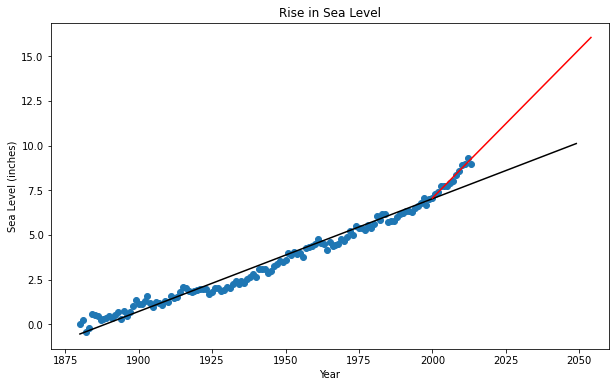

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x=df['Year'], y=df['CSIRO Adjusted Sea Level'])
ax.set_xlabel('Year')
ax.set_ylabel('Sea Level (inches)')
ax.set_title('Rise in Sea Level')

ax.set_xlim(1870, 2060)

years = range(1880, 2050)
ax.plot(years, res.slope * years + res.intercept, color='k')

recent_years = range(2000, 2055)
ax.plot(recent_years, recent_res.slope * recent_years + recent_res.intercept,
        color='r')